# Automobile Sales During Recession Periods
### An Exploratory Data Visualization Study (1980 – 2023)

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Folium  
**Dataset:** Historical automobile sales with macroeconomic indicators

---

## Overview
This notebook analyses how automobile sales behaved across six U.S. recessionary periods 
(1980, 1981–82, 1991, 2000–01, 2007–09, and the 2020 COVID-19 shock) compared with 
non-recession years. Using economic covariates such as consumer confidence, GDP, unemployment, 
advertising expenditure, and price, we surface patterns that can inform pricing, 
inventory, and marketing strategy for automotive stakeholders.

## Objectives
- Quantify the impact of recessions on sales volume and seasonality.
- Identify which vehicle segments are most resilient.
- Relate sales movement to consumer confidence, price, and unemployment.
- Compare advertising spend behaviour across economic cycles.
- Visualise geographic hotspots of recession-period sales.

In [1]:
# Uncomment to install dependencies in a fresh environment
# !pip install pandas numpy matplotlib seaborn folium requests

# Import necessary libraries
import io
import requests
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

In [2]:
# Data loading
URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"
)

response = requests.get(URL)
response.raise_for_status()
df = pd.read_csv(io.StringIO(response.text))
df.columns = df.columns.str.strip()          # normalise header whitespace
df["Date"] = pd.to_datetime(df["Date"])

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 2,112  |  Columns: 15


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [3]:
# Data quality check
df.info()
print("\nMissing values:\n", df.isna().sum())
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 2112 entries, 0 to 2111
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     2112 non-null   datetime64[us]
 1   Year                     2112 non-null   int64         
 2   Month                    2112 non-null   str           
 3   Recession                2112 non-null   int64         
 4   Consumer_Confidence      2112 non-null   float64       
 5   Seasonality_Weight       2112 non-null   float64       
 6   Price                    2112 non-null   int64         
 7   Advertising_Expenditure  2112 non-null   float64       
 8   Competition              2112 non-null   int64         
 9   GDP                      2112 non-null   float64       
 10  Growth_Rate              2112 non-null   float64       
 11  unemployment_rate        2112 non-null   float64       
 12  Automobile_Sales         2112 non-null   floa

,count,mean,min,25%,50%,75%,max,std
Date,2112,2002-01-20 16:12:57.272727,1980-01-31 00:00:00,1991-04-30 00:00:00,2002-02-28 00:00:00,2012-10-07 18:00:00,2023-12-31 00:00:00,NaN
Year,2112.0,2001.520833,1980.0,1991.0,2002.0,2012.0,2023.0,12.535031
Recession,2112.0,0.224432,0.0,0.0,0.0,0.0,1.0,0.417306
Consumer_Confidence,2112.0,101.21089,73.9,94.06,100.8,108.32,131.67,10.634092
Seasonality_Weight,2112.0,0.737756,0.25,0.5,0.81,0.94,1.5,0.286092
Price,2112.0,41469.506155,15001.0,22039.0,34957.5,57418.25,79998.0,21388.409141
Advertising_Expenditure,2112.0,2879.743655,494.2,1872.0,2883.5,3902.425,4983.0,1175.338324
Competition,2112.0,6.118845,3.0,4.0,6.0,8.0,9.0,1.964292
GDP,2112.0,40.205748,12.51,27.21,39.42,53.8625,70.37,16.291271
Growth_Rate,2112.0,-0.237074,-4.23,-0.57,-0.005,0.3925,0.82,0.859691


**Observation.** The dataset contains 2,112 monthly records spanning 1980–2023 with no missing values. 
Roughly **22 % of observations fall inside declared recession periods** (`Recession == 1`), 
giving a reasonable base for comparative analysis.

## 1.1  How have average automobile sales moved year over year?

The line chart below traces the mean monthly sales per year. Recession windows are 
annotated so we can visually associate inflection points with economic events.

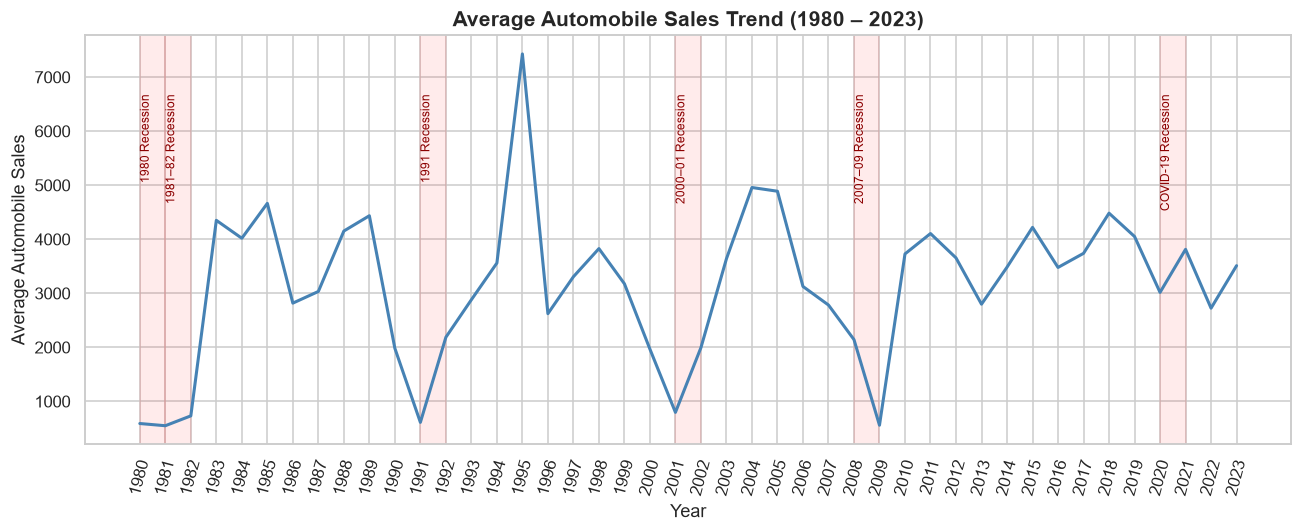

In [4]:
ave_sales = df.groupby("Year")["Automobile_Sales"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ave_sales.plot(kind="line", ax=ax, linewidth=2, color="steelblue")

ax.set_xticks(range(1980, 2024))
ax.set_xlabel("Year")
ax.set_ylabel("Average Automobile Sales")
ax.set_title("Average Automobile Sales Trend (1980 – 2023)", fontsize=14, weight="bold")
plt.xticks(rotation=75)

# Recession annotations
for year, label in [
    (1980, "1980 Recession"),
    (1981, "1981–82 Recession"),
    (1991, "1991 Recession"),
    (2001, "2000–01 Recession"),
    (2008, "2007–09 Recession"),
    (2020, "COVID-19 Recession"),
]:
    ax.axvspan(year, year + 1, color="red", alpha=0.08)
    ax.text(year, ave_sales.max() * 0.9, label, rotation=90,
            fontsize=8, color="darkred", va="top")

plt.tight_layout()
plt.show()

**Insight for stakeholders.**  
Sales track the economic cycle closely; every shaded recession window coincides with a 
local trough. The multi-year expansion between 2010–2019 lifted average sales to their 
highest sustained level in the series. The 2020 shock produced the sharpest year-over-year 
contraction, but the rebound in 2021–2022 was equally swift.  
*Actionable implication:* sales planning should treat recessions as **predictable, 
short-lived demand shocks** rather than structural declines.

## 1.2  Does advertising expenditure move with sales during non-recession years?

We isolate non-recession years and overlay average advertising spend against average sales.

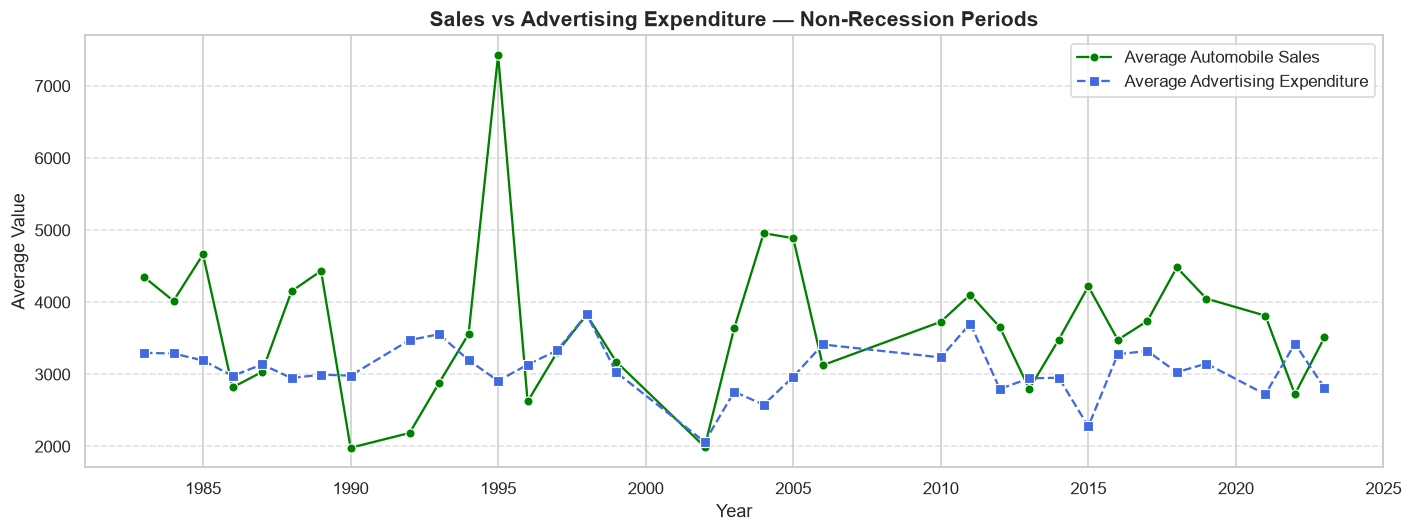

In [5]:
df_non_rec = df[df["Recession"] == 0]

df_non_trend = (
    df_non_rec.groupby("Year", as_index=False)
    .agg(avg_sales=("Automobile_Sales", "mean"),
         avg_ad_spend=("Advertising_Expenditure", "mean"))
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=df_non_trend, x="Year", y="avg_sales",
             marker="o", linestyle="-", color="green",
             label="Average Automobile Sales", ax=ax)
sns.lineplot(data=df_non_trend, x="Year", y="avg_ad_spend",
             marker="s", linestyle="--", color="royalblue",
             label="Average Advertising Expenditure", ax=ax)

ax.set_xlabel("Year"); ax.set_ylabel("Average Value")
ax.set_title("Sales vs Advertising Expenditure — Non-Recession Periods",
             fontsize=14, weight="bold")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()

**Insight for stakeholders.**  
Advertising spend is **far more stable** than sales, it fluctuates in a narrow band 
while sales swing widely year to year. This decoupling suggests XYZAutomotives maintains 
a baseline marketing budget regardless of short-term demand, and that advertising alone 
does not explain sales variance.  
*Actionable implication:* incremental sales gains in non-recession years likely come from 
**product mix, pricing, or macro demand** rather than marginal advertising increases.

## 1.3  Which vehicle segments are most affected by recessions?

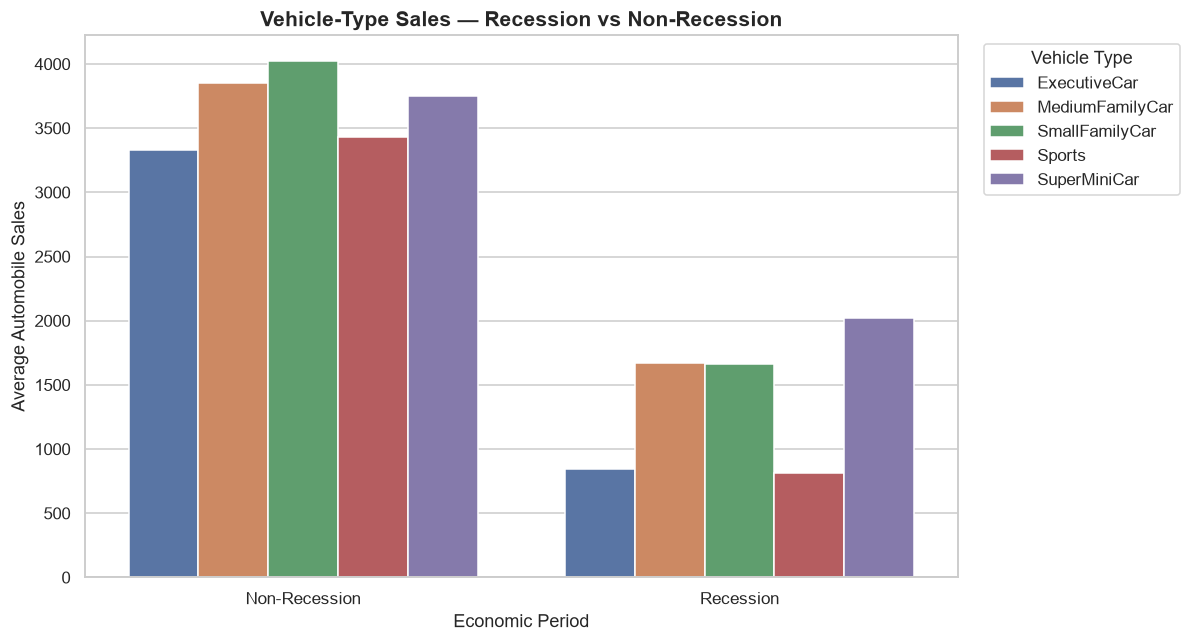

In [6]:
grouped_df = (
    df.groupby(["Recession", "Vehicle_Type"], as_index=False)["Automobile_Sales"].mean()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=grouped_df, x="Recession", y="Automobile_Sales",
            hue="Vehicle_Type", ax=ax)

ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-Recession", "Recession"])
ax.set_xlabel("Economic Period"); ax.set_ylabel("Average Automobile Sales")
ax.set_title("Vehicle-Type Sales — Recession vs Non-Recession",
             fontsize=14, weight="bold")
ax.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

**Insight for stakeholders.**  
Every vehicle category experiences a decline during recessions, but the contraction is 
**disproportionate**: Executive and Sports cars, the highest-margin, highest-price 
segments, lose the most volume. Entry-level SuperMiniCars and SmallFamilyCars prove 
more resilient, consistent with consumers trading down during economic stress.  
*Actionable implication:* rebalance inventory toward **affordable segments** as leading 
indicators (unemployment, consumer confidence) deteriorate.

## 1.4  How does GDP behave during recessions vs non-recession?

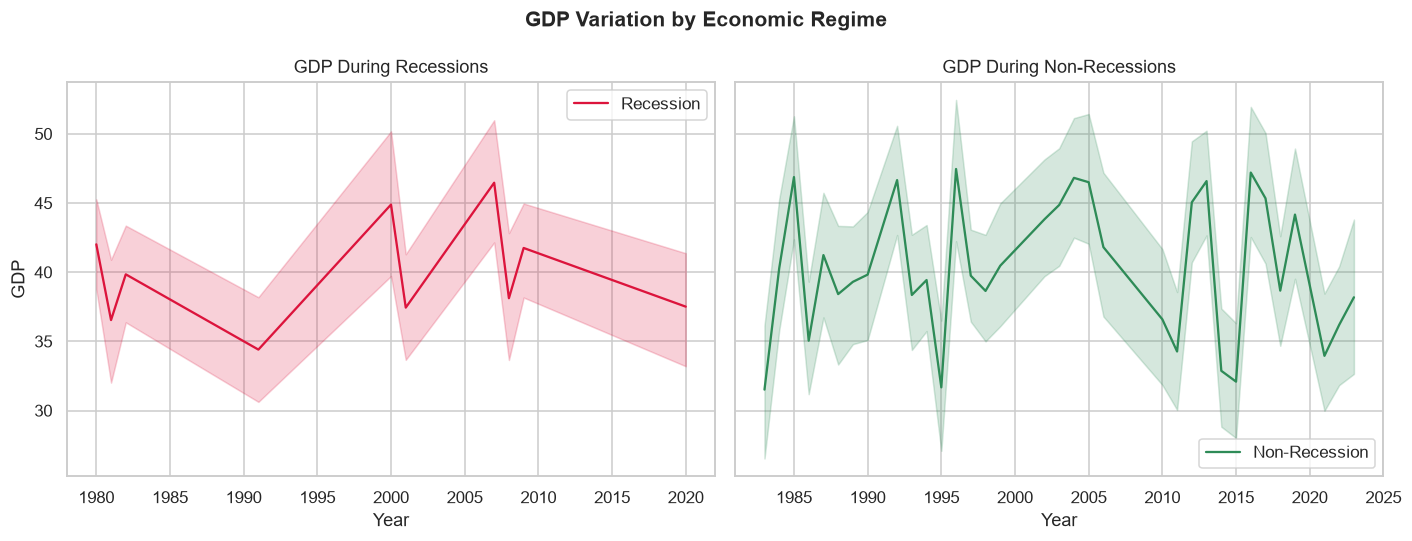

In [7]:
rec_data     = df[df["Recession"] == 1]
non_rec_data = df[df["Recession"] == 0]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

sns.lineplot(data=rec_data,     x="Year", y="GDP", label="Recession",     ax=ax0, color="crimson")
sns.lineplot(data=non_rec_data, x="Year", y="GDP", label="Non-Recession", ax=ax1, color="seagreen")

ax0.set_title("GDP During Recessions");       ax0.set_xlabel("Year"); ax0.set_ylabel("GDP")
ax1.set_title("GDP During Non-Recessions");   ax1.set_xlabel("Year")

plt.suptitle("GDP Variation by Economic Regime", fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

**Insight for stakeholders.**  
Recession-period GDP is both **lower on average and markedly more volatile**, the 
red panel shows frequent drawdowns and unstable trajectories, while the green panel 
shows a steadily rising GDP with only mild noise. This macro backdrop explains why 
discretionary purchases like automobiles stall when GDP falters.  
*Actionable implication:* use **GDP growth as a leading demand indicator** in the 
quarterly sales forecast.

## 1.5  How strong is the seasonal effect on sales?

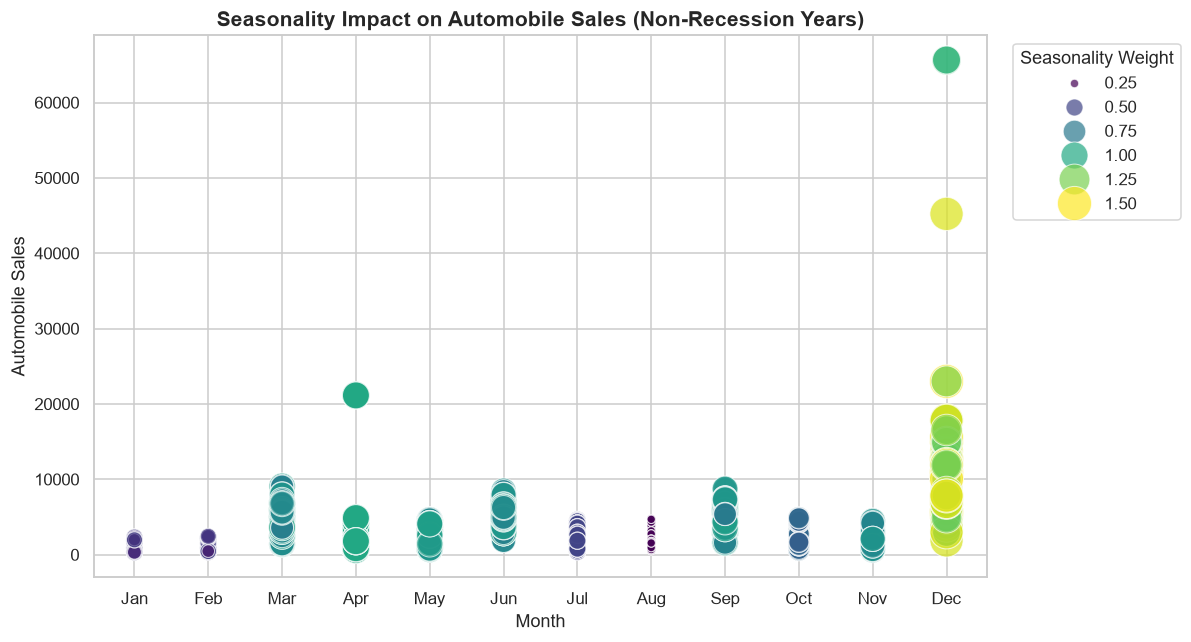

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(
    data=non_rec_data, x="Month", y="Automobile_Sales",
    size="Seasonality_Weight", hue="Seasonality_Weight",
    sizes=(30, 500), palette="viridis", alpha=0.7, ax=ax,
)
ax.set_xlabel("Month"); ax.set_ylabel("Automobile Sales")
ax.set_title("Seasonality Impact on Automobile Sales (Non-Recession Years)",
             fontsize=14, weight="bold")
ax.legend(title="Seasonality Weight", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

**Insight for stakeholders.**  
Bubble size represents the seasonal weighting for each month. **April and December** 
consistently register the largest bubbles and the highest sales; aligning with 
spring promotions and year-end model clearance. The off-peak months (Jan–Feb) show 
both smaller bubbles and lower sales, confirming the seasonal dip.  
*Actionable implication:* **concentrate promotional campaigns in April and December** 
and avoid tying fixed marketing budget to low-season months.

## 1.6  During recessions, how do consumer confidence and price relate to sales?

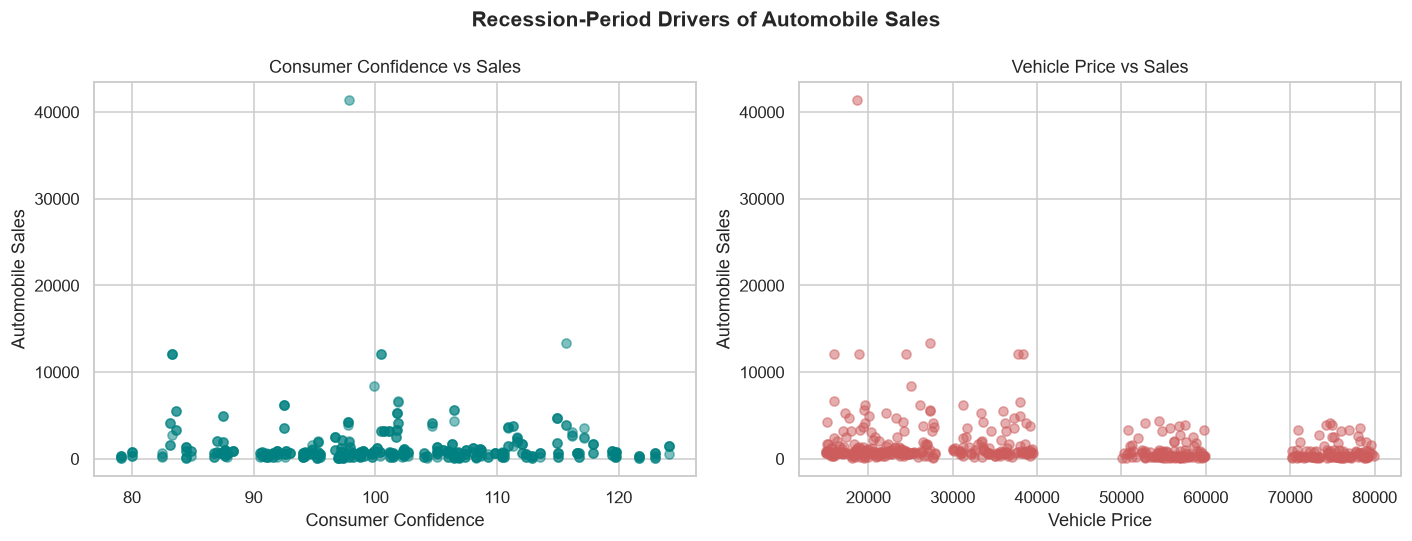

In [9]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5))

# Consumer confidence
ax0.scatter(rec_data["Consumer_Confidence"], rec_data["Automobile_Sales"],
            alpha=0.5, color="teal")
ax0.set_xlabel("Consumer Confidence"); ax0.set_ylabel("Automobile Sales")
ax0.set_title("Consumer Confidence vs Sales")

# Price
ax1.scatter(rec_data["Price"], rec_data["Automobile_Sales"],
            alpha=0.5, color="indianred")
ax1.set_xlabel("Vehicle Price"); ax1.set_ylabel("Automobile Sales")
ax1.set_title("Vehicle Price vs Sales")

plt.suptitle("Recession-Period Drivers of Automobile Sales",
             fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

**Insight for stakeholders.**  
Two clear patterns emerge during recessions:
1. **Higher consumer confidence → higher sales** (mild positive relationship).  
2. **Higher vehicle price → lower sales** (negative relationship; affordability is 
   paramount when budgets tighten).

*Actionable implication:* prioritise **affordable trims and financing incentives** when 
confidence is low; premium trims should be marketed once sentiment recovers.

## 1.7  Where is the advertising budget allocated?

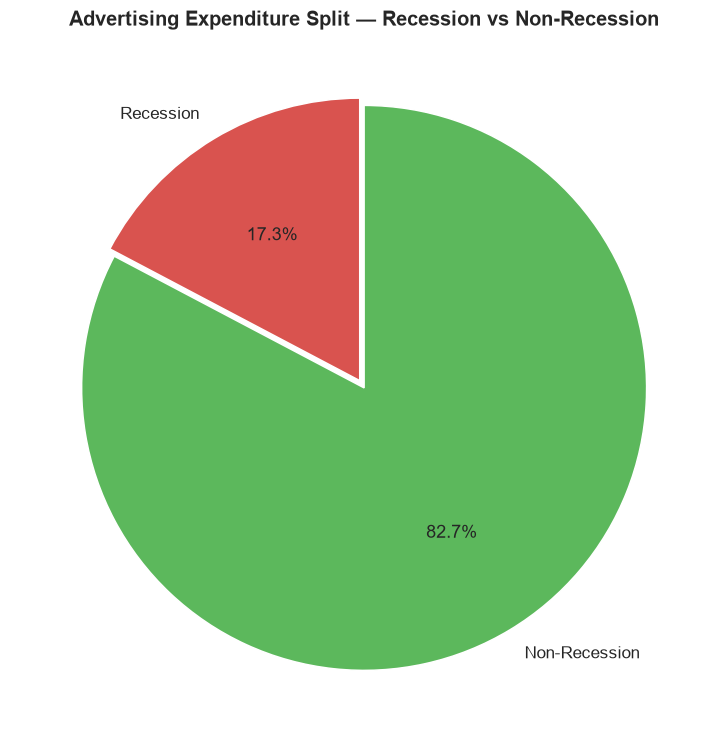

In [10]:
RAtotal  = rec_data["Advertising_Expenditure"].sum()
NRAtotal = non_rec_data["Advertising_Expenditure"].sum()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie([RAtotal, NRAtotal], labels=["Recession", "Non-Recession"],
       autopct="%1.1f%%", startangle=90,
       colors=["#d9534f", "#5cb85c"], explode=(0.03, 0))
ax.set_title("Advertising Expenditure Split — Recession vs Non-Recession",
             fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

**Insight for stakeholders.**  
XYZAutomotives spends the overwhelming majority of its advertising budget in 
**non-recession periods**. Only a small share is directed toward recessionary windows, 
implying a "wait for the recovery" marketing posture.  
*Actionable implication:* given that recessions historically last 8–18 months, 
**rebalancing a small portion of spend toward defensive, value-focused campaigns** 
during downturns could protect market share at a lower cost-per-impression.

## 1.8  Which segments receive the ad budget during recessions?

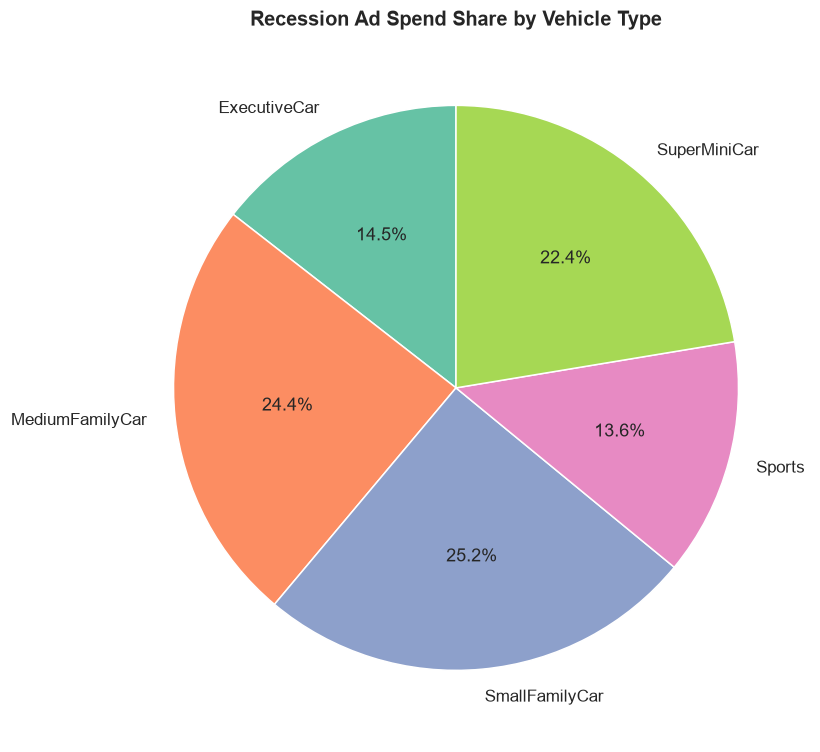

In [11]:
VT_exp = rec_data.groupby("Vehicle_Type")["Advertising_Expenditure"].sum()

fig, ax = plt.subplots(figsize=(9, 7))
ax.pie(VT_exp.values, labels=VT_exp.index, autopct="%1.1f%%",
       startangle=90, colors=sns.color_palette("Set2", len(VT_exp)))
ax.set_title("Recession Ad Spend Share by Vehicle Type",
             fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

**Insight for stakeholders.**  
During recessions, budget is concentrated on **SuperMiniCars, SmallFamilyCars, and 
MediumFamilyCars**, exactly the affordable segments that also hold up best in the 
sales data (Task 1.3). Executive and Sports segments receive comparatively little.  
*Actionable implication:* the current allocation is **strategically coherent**, 
advertising follows resilient demand. There is no evidence of budget waste during 
downturns.

## 1.9  What is the effect of unemployment on each segment?

ValueError: Could not interpret value `Unemployment_Rate` for `x`. An entry with this name does not appear in `data`.

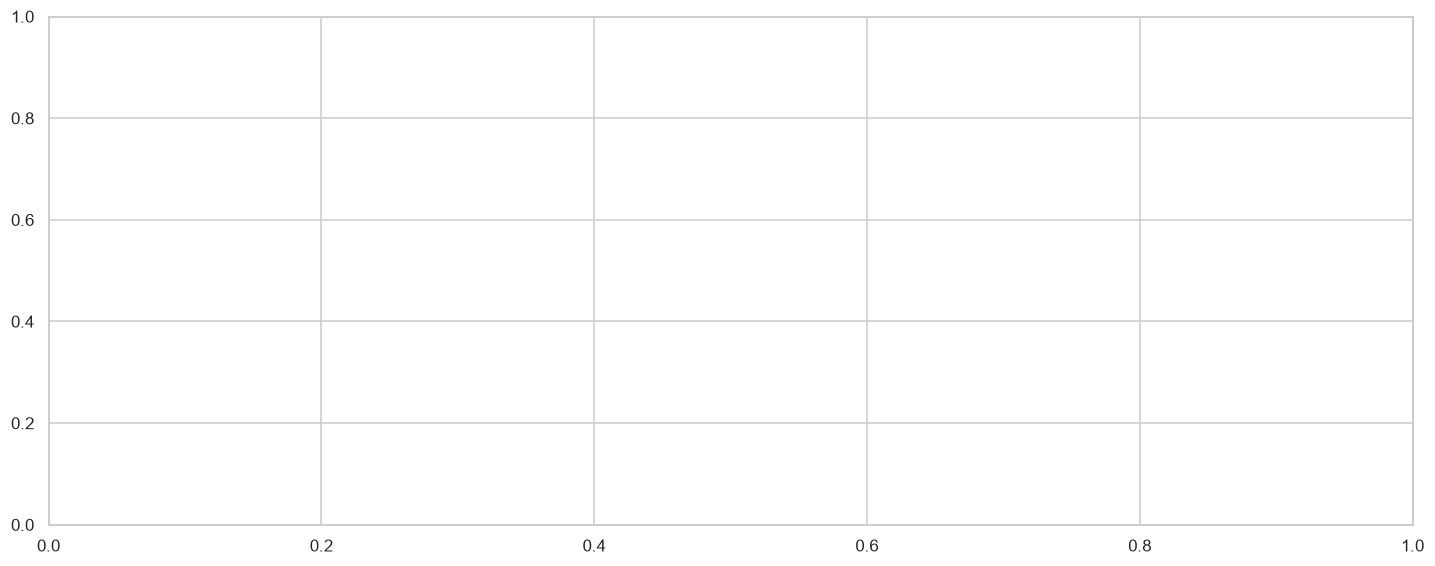

In [ ]:
df_rec = df[df["Recession"] == 1]

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(data=df_rec, x="unemployment_rate", y="Automobile_Sales",
             hue="Vehicle_Type", marker="o", ax=ax)
ax.set_title("Effect of Unemployment Rate on Vehicle Sales During Recessions",
             fontsize=14, weight="bold")
ax.set_xlabel("Unemployment Rate (%)"); ax.set_ylabel("Automobile Sales")
ax.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()